# Стохастический градиентный спуск

In [1]:
import sys
from pathlib import Path

src_path = Path("../src").resolve()
sys.path.append(str(src_path))

import numpy as np
from typing import Callable, List
import math
from sgd import sgd
from mytypes import Array
from show import show

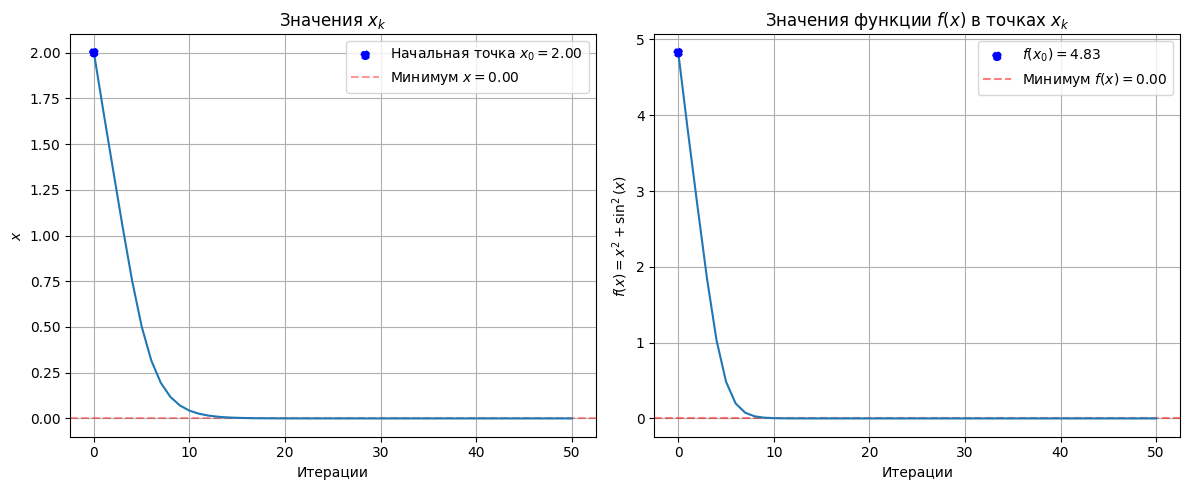

In [ ]:
def pl_func_sgd(x: Array) -> float:
    return x[0] ** 2 + (math.sin(x[0])) ** 2


def grad_pl_func_sgd(x: Array) -> Array:
    return np.array([2.0 * x[0] + math.sin(2.0 * x[0])], dtype=np.float64)


x0: Array = np.array([2.0], dtype=np.float64)
T: int = 50
alpha: Callable[[int], float] = lambda k: 0.1

x_vals: List[Array] = sgd(grad_pl_func_sgd, x0, T, alpha)
f_vals: List[float] = [pl_func_sgd(x) for x in x_vals]

show(x_vals, f_vals, ylabel2=r"$f(x) = x^2 + \sin^2(x)$")

alpha = -0.00357175653466775


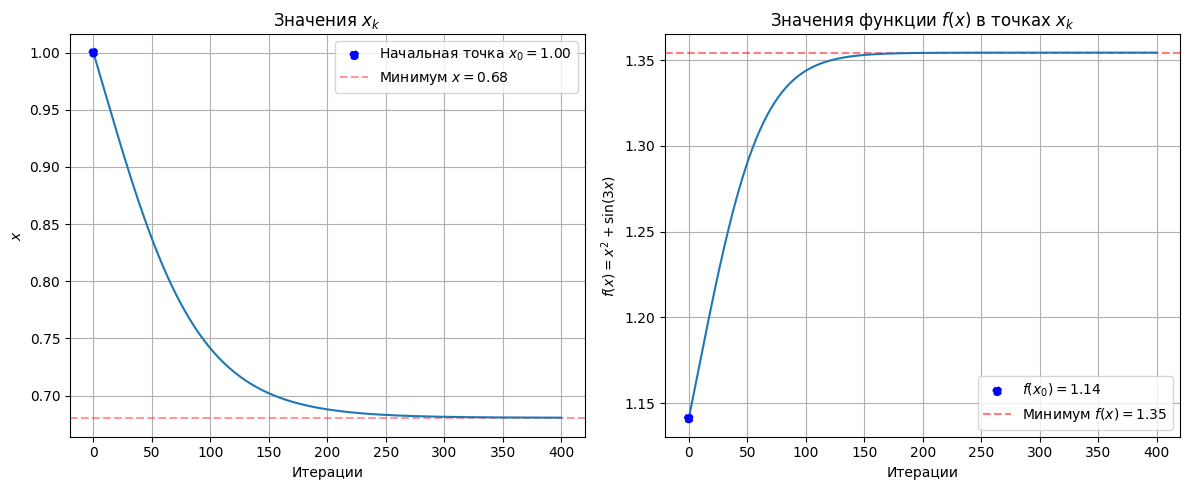

In [ ]:
def nonconv_func_sgd(x: Array) -> float:
    return x[0] ** 2 + math.sin(3.0 * x[0])


def grad_nonconv_func_sgd(x: Array) -> Array:
    return np.array(
        [2.0 * x[0] + 3.0 * math.cos(3.0 * x[0])], dtype=np.float64
    )


x0: Array = np.array([1.0], dtype=np.float64)
T: int = 400
L_f: float = 11.0
L_max: float = 11.0
alpha: Callable[[int], float] = (
    lambda k: math.sqrt(2.0 / (L_f * L_max * T)) - 0.01
)
print(f"alpha = {alpha(1)}")

x_vals: List[Array] = sgd(grad_nonconv_func_sgd, x0, T, alpha)
f_vals: List[float] = [nonconv_func_sgd(x) for x in x_vals]

show(
    x_vals, f_vals, ylabel2=r"$f(x) = x^2 + \sin(3x)$", x_min=0.68, f_min=1.354
)